In [ ]:
from data.voirie import get_voirie
import osmnx as ox

G = get_voirie(place="2nd arrondissement, Paris, France")

nodes, edges = ox.graph_to_gdfs(G)

In [15]:
# Graphe non-dirigé : une rue à double sens ne doit pas compter double
G_und = ox.convert.to_undirected(G)

# Nœuds terminaux = degré 1 dans le graphe non-dirigé
dead_end_nodes = {n for n, d in G_und.degree() if d == 1}

In [17]:
import pandas as pd

# Construire les arêtes menant à ces nœuds, avec leur longueur
dead_end_edges = []
for node in dead_end_nodes:
    for neighbor in G_und.neighbors(node):
        data = G_und.get_edge_data(node, neighbor)[0]
        dead_end_edges.append({
            "dead_end_node": node,
            "entry_node":    neighbor,
            "length":        data.get("length", 0),
            "name":          data.get("name", ""),
            "highway":       data.get("highway", ""),
        })

df_dead_ends = pd.DataFrame(dead_end_edges)

In [ ]:
def longueur_impasse(G_und, dead_end_node):
    """
    Remonte la chaîne depuis le nœud terminal jusqu'au premier carrefour.
    Retourne (longueur totale, liste des nœuds, nœud d'entrée).
    """
    longueur = 0
    chemin = [dead_end_node]
    courant = dead_end_node
    precedent = None

    while True:
        voisins = [n for n in G_und.neighbors(courant) if n != precedent]

        # Carrefour atteint : on s'arrête
        if len(voisins) != 1:
            return longueur, chemin, courant

        suivant = voisins[0]
        data = G_und.get_edge_data(courant, suivant)[0]
        longueur += data.get("length", 0)
        chemin.append(suivant)
        precedent = courant
        courant = suivant

In [ ]:
# Appliquer à tous les nœuds terminaux
impasses = []
for node in dead_end_nodes:
    longueur, chemin, entree = longueur_impasse(G_und, node)
    data = G_und.get_edge_data(chemin[-2], chemin[-1])[0] if len(chemin) > 1 else {}
    impasses.append({
        "dead_end_node": node,
        "entry_node":    entree,
        "longueur_m":   round(longueur),
        "nb_segments":  len(chemin) - 1,
        "name":         data.get("name", ""),
        "highway":      data.get("highway", ""),
        "chemin_nodes": chemin,
    })

df_impasses = pd.DataFrame(impasses).sort_values("longueur_m")

In [19]:
SEUIL_M = 100

a_ignorer = df_impasses[df_impasses["longueur_m"] < SEUIL_M]
a_couvrir  = df_impasses[df_impasses["longueur_m"] >= SEUIL_M]

# Retirer les nœuds des impasses courtes du graphe de routage
nodes_a_retirer = [n for chemin in a_ignorer["chemin_nodes"] for n in chemin[:-1]]
# On garde le nœud d'entrée (carrefour) — on retire seulement l'intérieur de l'impasse
G_propre = G.copy()
G_propre.remove_nodes_from(nodes_a_retirer)

print(f"Impasses ignorées  : {len(a_ignorer)} ({a_ignorer['longueur_m'].sum():.0f} m économisés)")
print(f"Impasses à couvrir : {len(a_couvrir)}")

Impasses ignorées  : 15 (556 m économisés)
Impasses à couvrir : 6


In [25]:
import geopandas as gpd
from shapely.geometry import LineString

# Construire un GeoDataFrame des impasses depuis df_impasses
# (chemin_nodes → géométrie en récupérant les coordonnées des nœuds)
nodes_gdf, edges_gdf = ox.graph_to_gdfs(G)

def chemin_to_geometry(chemin_nodes):
    """Reconstruit la LineString d'une impasse depuis ses nœuds."""
    coords = [
        (nodes_gdf.loc[n, "x"], nodes_gdf.loc[n, "y"])
        for n in chemin_nodes
        if n in nodes_gdf.index
    ]
    return LineString(coords) if len(coords) >= 2 else None

df_impasses["geometry"] = df_impasses["chemin_nodes"].apply(chemin_to_geometry)
gdf_impasses = gpd.GeoDataFrame(df_impasses.dropna(subset=["geometry"]), crs=edges_gdf.crs)

# Séparer ignorées / à couvrir
gdf_ignorees = gdf_impasses[gdf_impasses["longueur_m"] < SEUIL_M]
gdf_a_couvrir = gdf_impasses[gdf_impasses["longueur_m"] >= SEUIL_M]

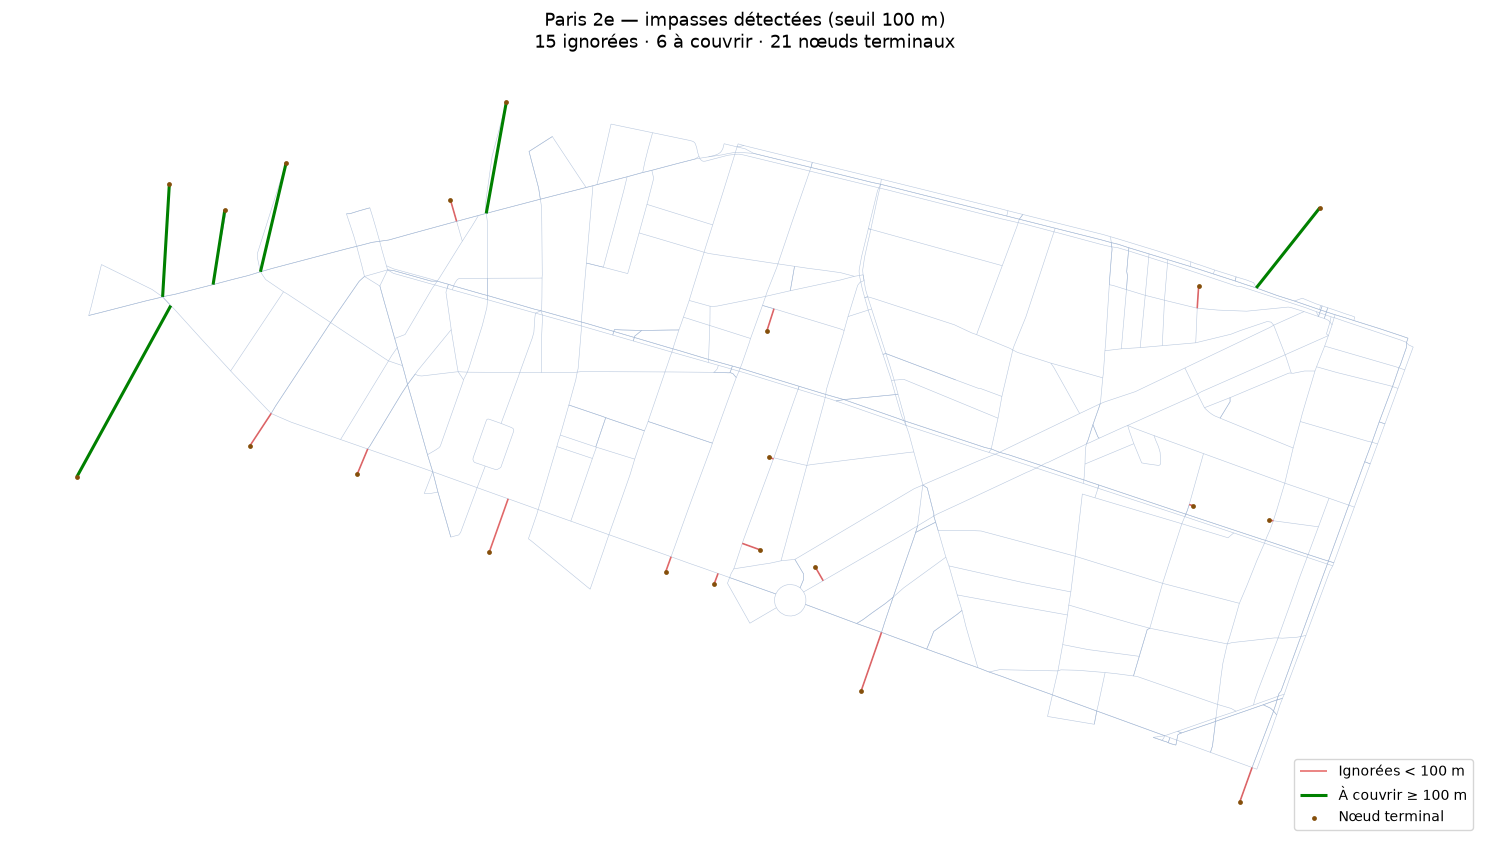

In [26]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(15, 15))  # facecolor par défaut = blanc

# Réseau complet — bleu plus visible sur fond blanc
edges_gdf.plot(ax=ax, color="#9ab0d0", linewidth=0.4, alpha=0.7)

# Impasses ignorées (< seuil) : rouge
gdf_ignorees.plot(ax=ax, color="#E24B4A", linewidth=1.2, alpha=0.8, label=f"Ignorées < {SEUIL_M} m")

# Impasses à couvrir (≥ seuil) : vert
gdf_a_couvrir.plot(ax=ax, color="#008000", linewidth=2.2, label=f"À couvrir ≥ {SEUIL_M} m")

# Nœuds terminaux
ax.scatter(
    [nodes_gdf.loc[n, "x"] for n in dead_end_nodes if n in nodes_gdf.index],
    [nodes_gdf.loc[n, "y"] for n in dead_end_nodes if n in nodes_gdf.index],
    s=12, color="#854F0B", zorder=5, label="Nœud terminal", linewidths=0
)

ax.set_title(
    f"Paris 2e — impasses détectées (seuil {SEUIL_M} m)\n"
    f"{len(gdf_ignorees)} ignorées · {len(gdf_a_couvrir)} à couvrir · {len(dead_end_nodes)} nœuds terminaux",
    fontsize=13, pad=14
)
ax.legend(fontsize=10, loc="lower right")
ax.set_axis_off()
plt.tight_layout()
plt.show()